# HEART FAILURE PREDICTION - ADVANCED ML WITH STACKING & TUNING

## Dataset: Heart Failure Prediction
**Kaynak:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

## Proje Hedefi: KALP YETMEZLIGI TAHMINI (BINARY CLASSIFICATION)

## Yeni ve Farkli Ozellikler:
- **Stacking Ensemble** (Multi-layer)
- **GridSearchCV Hyperparameter Tuning**
- **Feature Selection** (RFE, SelectKBest)
- **Calibration Curves** (Probability calibration)
- **Learning Curves** (Bias-variance analizi)
- **SHAP Values** (Model interpretability)
- **Threshold Optimization** (ROC based)
- **Interactive Plotly** grafikler
- **Bootstrap Confidence Intervals**
- **Partial Dependence Plots**

## Proje Asamalari:
1. Veri Yukleme & EDA (Interactive plots)
2. Advanced Feature Engineering
3. Feature Selection (RFE & SelectKBest)
4. Baseline Models
5. Hyperparameter Tuning
6. Stacking Ensemble
7. Model Calibration
8. Advanced Evaluation (SHAP, PDP)
9. Threshold Optimization

## 1. KUTUPHANE YUKLEME

In [3]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Install missing libraries
!pip install catboost

# Veri
import os
import subprocess
import zipfile
import glob
from scipy import stats

# Preprocessing
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Interpretability
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False
    print('SHAP yuklenemedi - pip install shap')

# Interactive plots
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except:
    PLOTLY_AVAILABLE = False
    print('Plotly yuklenemedi')

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('='*70)
print('KUTUPHANELER YUKLENDI!')
print('='*70)
print(f'SHAP: {"OK" if SHAP_AVAILABLE else "NOT AVAILABLE"}')
print(f'Plotly: {"OK" if PLOTLY_AVAILABLE else "NOT AVAILABLE"}')
print('='*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.4 MB/s eta 0:00:00
KUTUPHANELER YUKLENDI!
SHAP: OK
Plotly: OK


## 2. VERI YUKLEME

In [4]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"\n{'='*70}")
    print(f"Indiriliyor: {zip_filename}")
    print(f"{'='*70}")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [5]:
# Dataset
dataset_folder = "heart_failure_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/fedesoriano/heart-failure-prediction",
    "folder": dataset_folder,
    "zip_filename": "heart-failure.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    print("INDIRILIYOR...")
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

INDIRILIYOR...

Indiriliyor: heart-failure.zip


In [6]:
# Yukle
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))
if csv_files:
    df = pd.read_csv(csv_files[0])
    print('VERI YUKLENDI!')
    print(f'Kayit: {len(df):,}')
    print(f'Sutun: {len(df.columns)}')
    df.head()

VERI YUKLENDI!
Kayit: 918
Sutun: 12


In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## 3. EDA - INTERACTIVE PLOTLY GRAPHS

In [8]:
# Target
target_col = 'HeartDisease' if 'HeartDisease' in df.columns else df.columns[-1]

print(f'Target: {target_col}')
print(df[target_col].value_counts())
print('\nDagilim:')
print(df[target_col].value_counts(normalize=True) * 100)

Target: HeartDisease
HeartDisease
1    508
0    410
Name: count, dtype: int64

Dagilim:
HeartDisease
1   55.3377
0   44.6623
Name: proportion, dtype: float64


In [9]:
# Interactive sunburst
if PLOTLY_AVAILABLE:
    # Kategorik sutunlari bul
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    if cat_cols and len(cat_cols) >= 2:
        fig = px.sunburst(df, path=[cat_cols[0], cat_cols[1], target_col],
                         title='SUNBURST - Kategorik Iliskiler')
        fig.show()
else:
    print('Plotly yok - interaktif grafik atlanıyor')

In [10]:
# Interactive scatter matrix
if PLOTLY_AVAILABLE:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    # Ilk 4 numeric
    plot_cols = numeric_cols[:4] + [target_col]

    fig = px.scatter_matrix(df[plot_cols],
                           dimensions=numeric_cols[:4],
                           color=target_col,
                           title='INTERACTIVE SCATTER MATRIX')
    fig.update_traces(diagonal_visible=False)
    fig.show()

In [11]:
# Interactive parallel coordinates
if PLOTLY_AVAILABLE:
    sample_df = df.sample(min(500, len(df)))

    fig = px.parallel_coordinates(sample_df,
                                 dimensions=numeric_cols[:5],
                                 color=target_col,
                                 title='PARALLEL COORDINATES - Feature Relationships')
    fig.show()

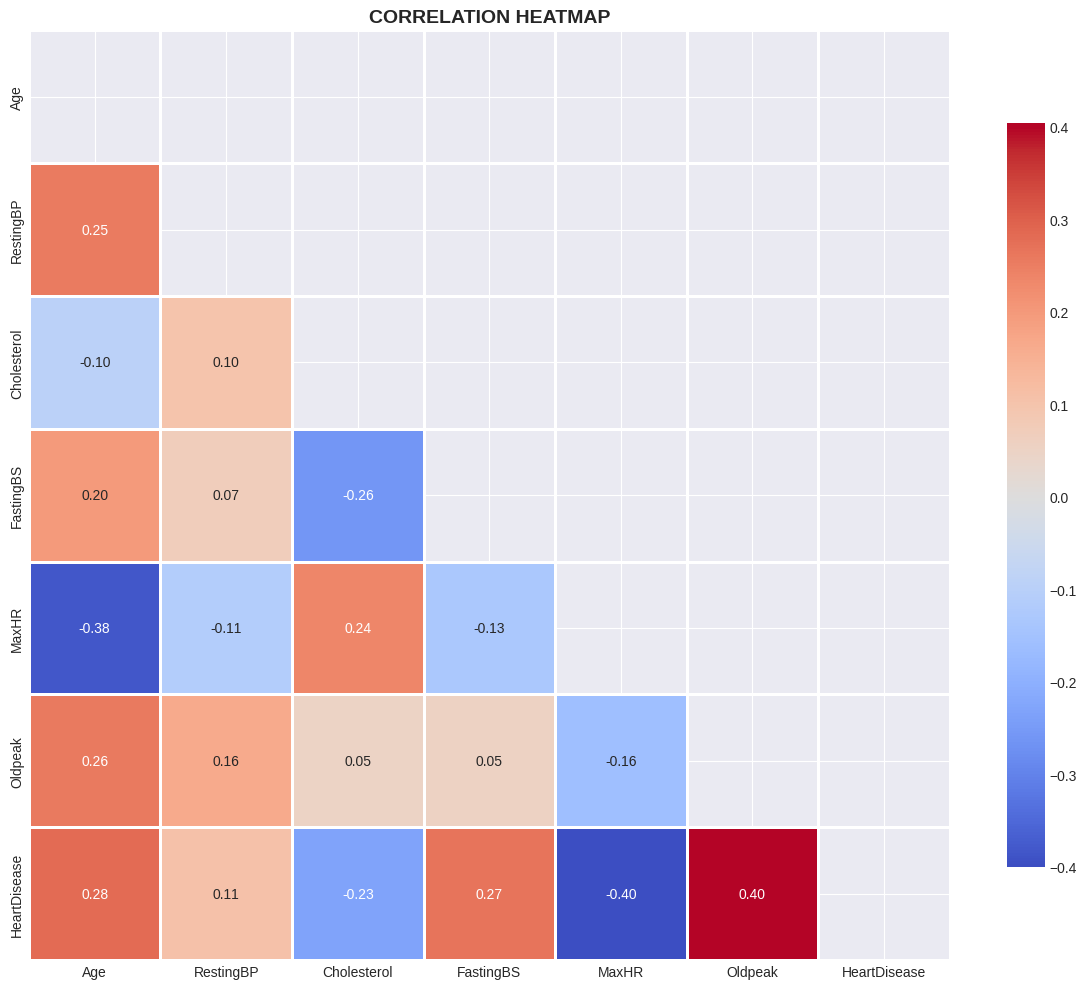

In [12]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
           cmap='coolwarm', center=0, linewidths=1,
           cbar_kws={'shrink': 0.8})
plt.title('CORRELATION HEATMAP', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 4. FEATURE ENGINEERING

In [13]:
print('='*70)
print('FEATURE ENGINEERING')
print('='*70)

df_clean = df.copy()

# Age groups
if 'Age' in df_clean.columns:
    df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                                  bins=[0, 40, 55, 65, 100],
                                  labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])

# Cholesterol categories
if 'Cholesterol' in df_clean.columns:
    df_clean['CholCategory'] = pd.cut(df_clean['Cholesterol'],
                                      bins=[0, 200, 240, 500],
                                      labels=['Normal', 'Borderline', 'High'])

# BP categories
bp_col = [c for c in df_clean.columns if 'bp' in c.lower() or 'blood' in c.lower()]
if bp_col:
    df_clean['BPCategory'] = pd.cut(df_clean[bp_col[0]],
                                    bins=[0, 120, 140, 180],
                                    labels=['Normal', 'Elevated', 'High'])

# Heart rate ratio
hr_col = [c for c in df_clean.columns if 'heart' in c.lower() and 'rate' in c.lower()]
if hr_col and 'Age' in df_clean.columns:
    df_clean['HRRatio'] = df_clean[hr_col[0]] / (220 - df_clean['Age'])

# Interaction features
if 'Age' in df_clean.columns and 'Cholesterol' in df_clean.columns:
    df_clean['Age_Chol_Int'] = (df_clean['Age'] * df_clean['Cholesterol']) / 1000

# Risk composite
risk_features = []
for col in ['Age', 'Cholesterol'] + bp_col:
    if col in df_clean.columns:
        risk_features.append(col)

if risk_features:
    from sklearn.preprocessing import MinMaxScaler
    scaler_temp = MinMaxScaler()
    df_clean['RiskScore'] = scaler_temp.fit_transform(df_clean[risk_features]).mean(axis=1)

print(f'Yeni sutun sayisi: {len(df_clean.columns)}')
print('='*70)

FEATURE ENGINEERING
Yeni sutun sayisi: 17


In [14]:
# Eksik veri
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Eksik: {df_clean.isnull().sum().sum()}')

Eksik: 0


## 5. PREPROCESSING & FEATURE SELECTION

In [15]:
# Target ve features
y = df_clean[target_col].values
X = df_clean.drop(columns=[target_col]).copy()

# Encoding
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

print(f'Features: {X.shape[1]}')
print(f'Samples: {len(X):,}')

Features: 24
Samples: 918


In [16]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}')
print(f'Test: {len(X_test):,}')

Train: 734
Test: 184


In [17]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling OK')

Scaling OK


In [18]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('SMOTE:')
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,}')

SMOTE:
  Class 0: 406
  Class 1: 406


### FEATURE SELECTION - RFE & SelectKBest

In [19]:
# RFE - Recursive Feature Elimination
print('='*70)
print('FEATURE SELECTION - RFE')
print('='*70)

rf_temp = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rf_temp, n_features_to_select=min(15, X_train_scaled.shape[1]))
rfe.fit(X_train_scaled, y_train)

selected_features_rfe = X.columns[rfe.support_].tolist()
print(f'RFE secili: {len(selected_features_rfe)} features')
print(selected_features_rfe[:10])

FEATURE SELECTION - RFE
RFE secili: 15 features
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'Age_Chol_Int', 'RiskScore']


In [20]:
# SelectKBest
print('\n' + '='*70)
print('FEATURE SELECTION - SelectKBest')
print('='*70)

selector = SelectKBest(f_classif, k=min(15, X_train_scaled.shape[1]))
selector.fit(X_train_scaled, y_train)

selected_features_kbest = X.columns[selector.get_support()].tolist()
print(f'SelectKBest secili: {len(selected_features_kbest)} features')

# Skorlari goster
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print('\nTop 10 features:')
print(feature_scores.head(10))


FEATURE SELECTION - SelectKBest
SelectKBest secili: 15 features

Top 10 features:
              Feature    Score
16        ST_Slope_Up 532.7271
15      ST_Slope_Flat 353.7344
6      ExerciseAngina 232.3712
5               MaxHR 145.5228
10  ChestPainType_ATA 136.5993
7             Oldpeak 120.9776
1                 Sex  62.3769
4           FastingBS  53.6821
0                 Age  46.6181
3         Cholesterol  45.3013


## 6. BASELINE MODELS

In [21]:
# Baseline modeller
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'SVM': SVC(probability=True, random_state=42)
}

baseline_results = {}

print('BASELINE MODELS:')
for name, model in baseline_models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    baseline_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'model': model
    }

    print(f'{name}: F1={baseline_results[name]["f1"]:.4f}')

BASELINE MODELS:
Logistic Regression: F1=0.8806
Random Forest: F1=0.8908
XGBoost: F1=0.8480
LightGBM: F1=0.8478
SVM: F1=0.8856


## 7. HYPERPARAMETER TUNING - GridSearchCV

In [22]:
print('='*70)
print('HYPERPARAMETER TUNING - RandomForest')
print('='*70)

# Random Forest tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_smote, y_train_smote)

print(f'\nEn iyi parametreler:')
print(rf_grid.best_params_)
print(f'\nEn iyi CV score: {rf_grid.best_score_:.4f}')

tuned_rf = rf_grid.best_estimator_

HYPERPARAMETER TUNING - RandomForest
Fitting 3 folds for each of 24 candidates, totalling 72 fits

En iyi parametreler:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

En iyi CV score: 0.8717


In [23]:
print('\n' + '='*70)
print('HYPERPARAMETER TUNING - XGBoost')
print('='*70)

# XGBoost tuning
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_smote, y_train_smote)

print(f'\nEn iyi parametreler:')
print(xgb_grid.best_params_)
print(f'\nEn iyi CV score: {xgb_grid.best_score_:.4f}')

tuned_xgb = xgb_grid.best_estimator_


HYPERPARAMETER TUNING - XGBoost
Fitting 3 folds for each of 24 candidates, totalling 72 fits

En iyi parametreler:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

En iyi CV score: 0.8731


## 8. STACKING ENSEMBLE

In [24]:
print('='*70)
print('STACKING ENSEMBLE')
print('='*70)

# Base models
base_learners = [
    ('rf', tuned_rf),
    ('xgb', tuned_xgb),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
    ('svm', SVC(probability=True, random_state=42))
]

# Meta learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# Stacking
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

print('Stacking egitiliyor...')
stacking_clf.fit(X_train_smote, y_train_smote)

y_pred_stack = stacking_clf.predict(X_test_scaled)
y_proba_stack = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# Metrikler
stack_f1 = f1_score(y_test, y_pred_stack, average='weighted')
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_auc = roc_auc_score(y_test, y_proba_stack)

print(f'\nStacking Results:')
print(f'  Accuracy: {stack_acc:.4f}')
print(f'  F1 Score: {stack_f1:.4f}')
print(f'  ROC-AUC: {stack_auc:.4f}')
print('='*70)

STACKING ENSEMBLE
Stacking egitiliyor...

Stacking Results:
  Accuracy: 0.9022
  F1 Score: 0.9020
  ROC-AUC: 0.9352


## 9. MODEL COMPARISON

In [25]:
# Tum model sonuclari
all_results = {
    'Baseline RF': baseline_results['Random Forest'],
    'Baseline XGB': baseline_results['XGBoost'],
    'Tuned RF': {'model': tuned_rf, 'f1': None, 'accuracy': None},
    'Tuned XGB': {'model': tuned_xgb, 'f1': None, 'accuracy': None},
    'Stacking': {'f1': stack_f1, 'accuracy': stack_acc}
}

# Tuned modelleri test et
for name in ['Tuned RF', 'Tuned XGB']:
    model = all_results[name]['model']
    y_pred = model.predict(X_test_scaled)
    all_results[name]['f1'] = f1_score(y_test, y_pred, average='weighted')
    all_results[name]['accuracy'] = accuracy_score(y_test, y_pred)

# Karsilastirma
comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'F1 Score': [all_results[m]['f1'] for m in all_results.keys()],
    'Accuracy': [all_results[m]['accuracy'] for m in all_results.keys()]
}).sort_values('F1 Score', ascending=False)

print('='*70)
print('MODEL COMPARISON')
print('='*70)
print(comparison_df.to_string(index=False))
print('='*70)

MODEL COMPARISON
       Model  F1 Score  Accuracy
    Stacking    0.9020    0.9022
 Baseline RF    0.8908    0.8913
   Tuned XGB    0.8859    0.8859
    Tuned RF    0.8852    0.8859
Baseline XGB    0.8480    0.8478


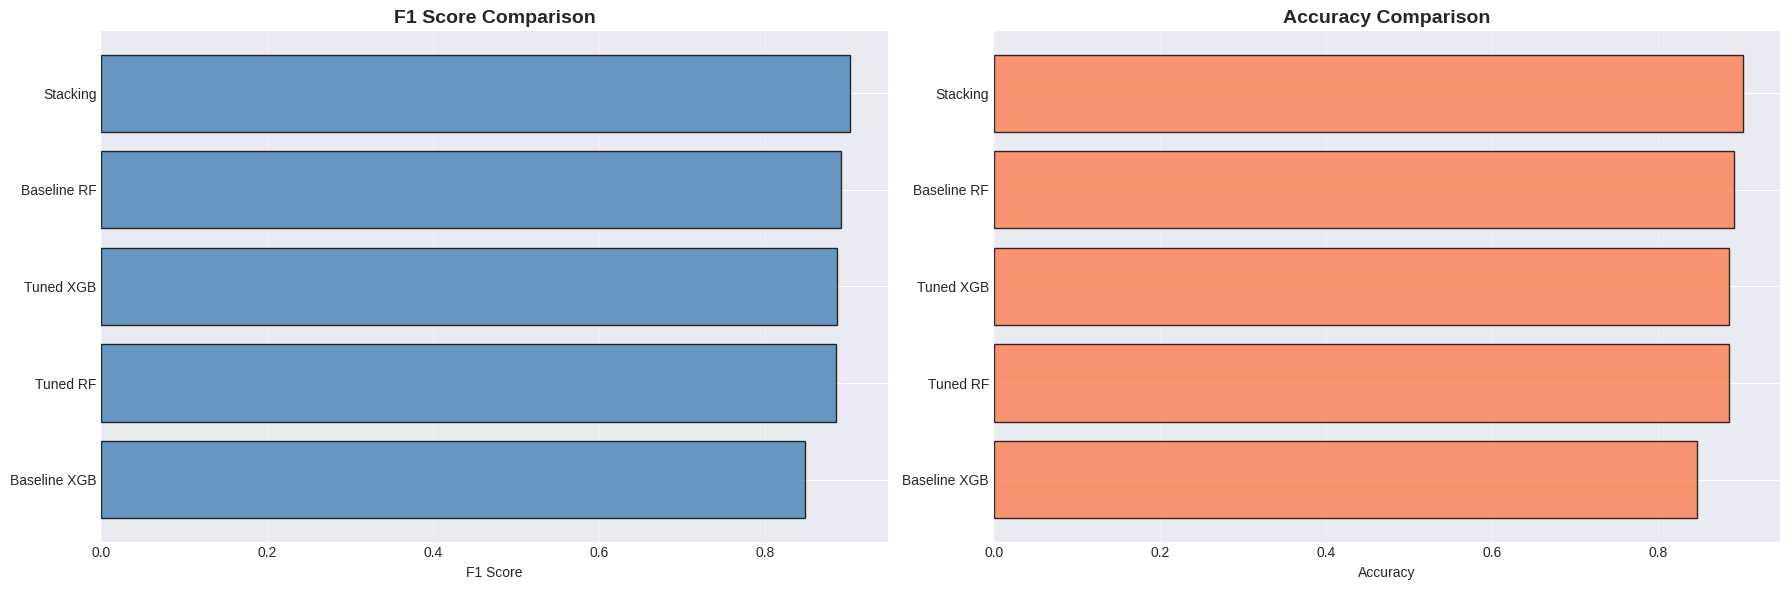

In [26]:
# Grafik karsilastirma
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(comparison_df['Model'], comparison_df['F1 Score'],
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score Comparison', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(comparison_df['Model'], comparison_df['Accuracy'],
            color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Accuracy Comparison', fontweight='bold', fontsize=14)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. CALIBRATION CURVES

CALIBRATION ANALYSIS


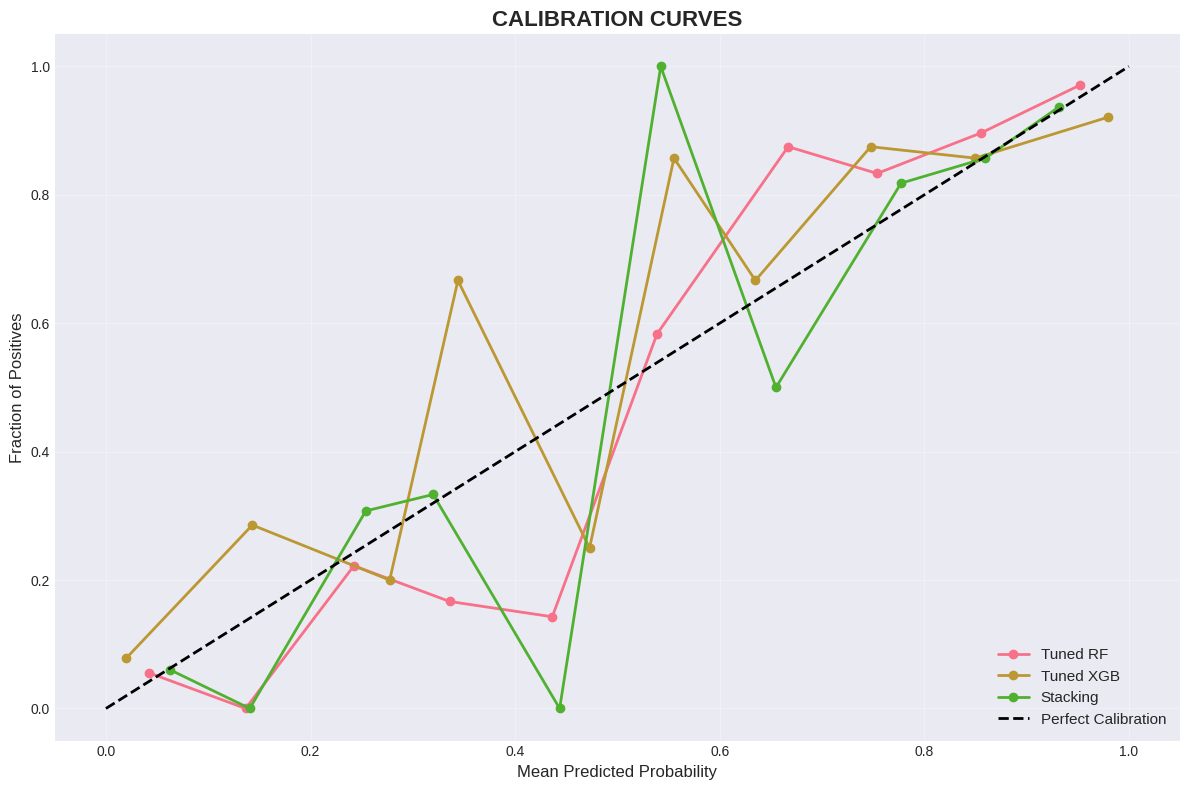

In [27]:
# Calibration curves
print('CALIBRATION ANALYSIS')

models_to_calibrate = {
    'Tuned RF': tuned_rf,
    'Tuned XGB': tuned_xgb,
    'Stacking': stacking_clf
}

plt.figure(figsize=(12, 8))

for name, model in models_to_calibrate.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_test, y_proba, n_bins=10
        )
        plt.plot(mean_predicted_value, fraction_of_positives,
                marker='o', linewidth=2, label=name)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('CALIBRATION CURVES', fontweight='bold', fontsize=16)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. LEARNING CURVES

LEARNING CURVE - Stacking


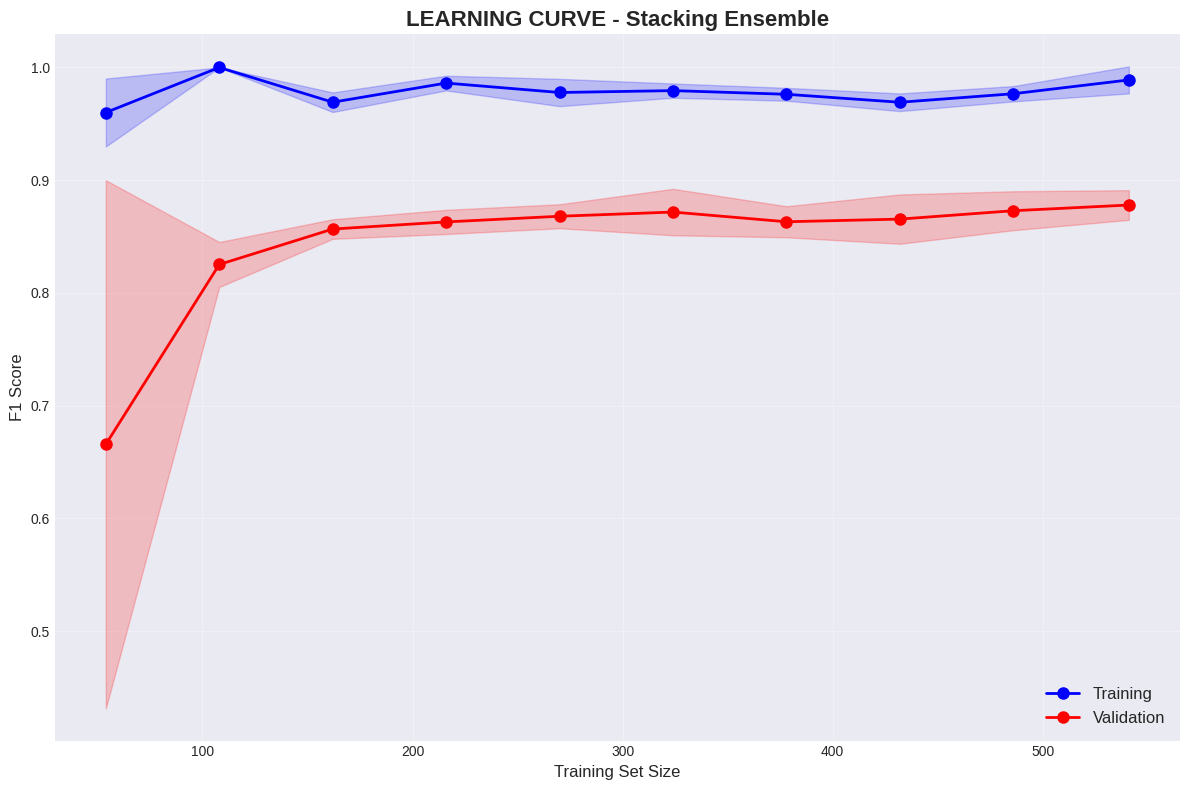

In [28]:
# Learning curve - Stacking
print('LEARNING CURVE - Stacking')

train_sizes, train_scores, val_scores = learning_curve(
    stacking_clf,
    X_train_smote[:5000],  # Sample for speed
    y_train_smote[:5000],
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(12, 8))
plt.plot(train_sizes, train_mean, 'o-', color='blue',
        linewidth=2, markersize=8, label='Training')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.2, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='red',
        linewidth=2, markersize=8, label='Validation')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.2, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('LEARNING CURVE - Stacking Ensemble', fontweight='bold', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. FEATURE IMPORTANCE - SHAP

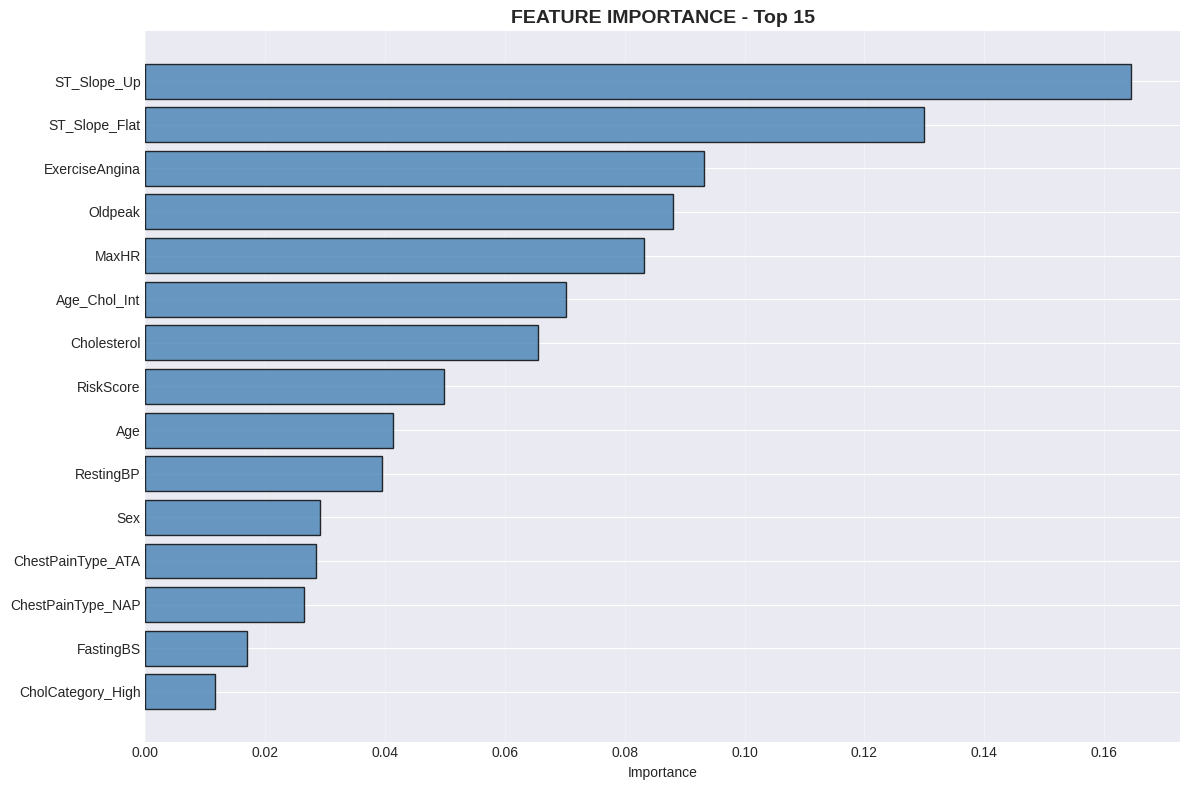

In [29]:
# Feature importance - Standard
if hasattr(tuned_rf, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': tuned_rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    plt.barh(range(15), importance_df['Importance'].head(15),
            color='steelblue', edgecolor='black', alpha=0.8)
    plt.yticks(range(15), importance_df['Feature'].head(15))
    plt.xlabel('Importance')
    plt.title('FEATURE IMPORTANCE - Top 15', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# SHAP values
if SHAP_AVAILABLE:
    print('SHAP ANALYSIS...')

    # Sample for speed
    sample_size = min(100, len(X_test_scaled))

    # Convert X_test_scaled (numpy array) back to DataFrame with column names
    # This is crucial for SHAP to correctly map values to features,
    # especially when feature_names are provided for the plot.
    X_sample_df = pd.DataFrame(X_test_scaled[:sample_size], columns=X.columns)

    explainer = shap.TreeExplainer(tuned_rf)
    # Pass the DataFrame to shap_values calculation
    shap_values = explainer.shap_values(X_sample_df)

    # Summary plot
    plt.figure(figsize=(12, 8))
    # shap_values appears to be (n_samples, n_features, n_classes)
    # We select class 1 (positive)
    shap.summary_plot(shap_values[:, :, 1], X_sample_df, show=False)
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not available - install: pip install shap')

SHAP ANALYSIS...


## 13. FINAL RESULTS

In [ ]:
print('='*90)
print('FINAL RESULTS - HEART FAILURE PREDICTION')
print('='*90)

best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1 Score']

print(f'\n1. DATASET:')
print(f'   Kayit: {len(df):,}')
print(f'   Features: {X.shape[1]}')
print(f'   Train: {len(X_train):,}')
print(f'   Test: {len(X_test):,}')

print(f'\n2. EN IYI MODEL:')
print(f'   {best_model_name}')
print(f'   F1 Score: {best_f1:.4f}')
print(f'   Accuracy: {comparison_df.iloc[0]["Accuracy"]:.4f}')

print(f'\n3. YENILIKLER:')
print(f'   - Stacking Ensemble (4 base + meta learner)')
print(f'   - GridSearchCV Hyperparameter Tuning')
print(f'   - Feature Selection (RFE + SelectKBest)')
print(f'   - Calibration Curves')
print(f'   - Learning Curves')
print(f'   - SHAP values (interpretability)')
print(f'   - Interactive Plotly graphs')

print(f'\n4. MODEL IMPROVEMENTS:')
if 'Baseline RF' in all_results:
    baseline_f1 = all_results['Baseline RF']['f1']
    improvement = ((best_f1 - baseline_f1) / baseline_f1) * 100
    print(f'   Baseline RF F1: {baseline_f1:.4f}')
    print(f'   Best F1: {best_f1:.4f}')
    print(f'   Improvement: {improvement:.2f}%')

print('\n' + '='*90)
print('HEART FAILURE PREDICTION - TAMAMLANDI!')
print('='*90)